# Word2Vec - Skip-Gram 模型

## 核心概念
Word2Vec 是一種將文字轉換為「向量」的技術，讓電腦能夠理解詞彙之間的語義關係。
Skip-Gram 是 Word2Vec 的兩種實現方式之一：**給定中心詞，預測周圍的詞**。

## 數學原理
$$P(w_{t+j} | w_t) = \text{softmax}(W' \cdot W \cdot x_t)$$

其中 $j \in [-k, k]$ 且 $j \neq 0$

- **輸入**：中心詞 (Center Word)
- **輸出**：預測周圍的上下文詞彙 (Context Words)
- **副產物**：訓練完成後，權重矩陣 $W$ 就是我們要的詞向量！

## Skip-Gram vs CBOW
| 特性 | Skip-Gram | CBOW |
|------|-----------|------|
| 預測方向 | 中心詞 → 周圍詞 | 周圍詞 → 中心詞 |
| 適用場景 | 小型語料庫、稀有詞 | 大型語料庫、常見詞 |
| 訓練速度 | 較慢 | 較快 |
| 效果 | 對稀有詞效果較好 | 對高頻詞效果較好 |

## 為什麼詞向量有用？
透過「分布假說」：**出現在相似上下文的詞，語義也相似**
- 「Kage」和「Mazong」都有「is」在後面 → 可能有相似的角色特徵
- 「Teacher」、「Boss」、「Student」都出現在「is」之後 → 都是身份描述

## 應用場景
- **語義相似度**：找出意思相近的詞彙
- **文本分類**：將詞向量作為特徵輸入分類器
- **命名實體識別**：利用詞向量的語義資訊
- **機器翻譯**：跨語言的詞向量對齊
- **推薦系統**：計算用戶興趣的語義相似度

In [10]:
"""
Step 1: 資料預處理（建立辭典）
定義原始句子（訓練語料）
"""

sentences = ["Kage is Teacher", "Mazong is Boss", "Niuzong is Boss",
             "Xiaobing is Student", "Xiaoxue is Student"]

# 2. 建立詞彙表
# 將所有句子合併並分割成單字清單
words = ' '.join(sentences).split()
word_list = list(set(words)) # 去除重複

# 3. 建立對照表（Dictionary mapping）
# word_to_idx: 文字 -> 數字
word_to_idx = {word: idx for idx, word in enumerate(word_list)}
# idx_to_word: 數字 -> 文字
idx_to_word = {idx: word for idx, word in enumerate(word_list)}

voc_size = len(word_list)

print(f"詞彙表大小: {voc_size}")
print(f"文字到索引的對照: {word_to_idx}")
print(f"索引到文字的對照: {idx_to_word}")

詞彙表大小: 9
文字到索引的對照: {'Niuzong': 0, 'Student': 1, 'Kage': 2, 'Xiaoxue': 3, 'Mazong': 4, 'Boss': 5, 'Teacher': 6, 'is': 7, 'Xiaobing': 8}
索引到文字的對照: {0: 'Niuzong', 1: 'Student', 2: 'Kage', 3: 'Xiaoxue', 4: 'Mazong', 5: 'Boss', 6: 'Teacher', 7: 'is', 8: 'Xiaobing'}


In [2]:
"""
Step 2: 生成訓練資料對（鄰居關係）
Skip-Gram 的邏輯是：給定「中心詞」，預測「周圍詞」。
"""

def create_skipgram_dataset(sentences, window_size=1):
    data = []
    for sentence in sentences:
        tokens = sentence.split()
        for idx, word in enumerate(tokens):
            # 找出當前單字周圍 window_size 範圍內的鄰居
            start = max(idx - window_size, 0)
            end = min(idx + window_size + 1, len(tokens))

            for neighbor in tokens[start:end]:
                if neighbor != word:
                    # (中心詞, 周圍詞)
                    data.append((word, neighbor))
    return data

skipgram_data = create_skipgram_dataset(sentences)
print(f"前 3 筆訓練樣本 (中心詞, 周圍詞): {skipgram_data[:3]}")

前 3 筆訓練樣本 (中心詞, 周圍詞): [('Kage', 'is'), ('is', 'Kage'), ('is', 'Teacher')]


In [3]:
"""
Step 3: 數值化處理（One-Hot Encoding）
神經網路不能直接運算文字，必須轉成向量。這裡使用 One-Hot Encoding。
"""

import torch

def one_hot_encoding(word, word_to_idx):
    # 建立一個全為 0 的張量，長度為詞彙表大小
    tensor = torch.zeros(len(word_to_idx))
    # 將該單字對應的索引位置設為 1
    tensor[word_to_idx[word]] = 1
    return tensor

# 範例展示
example_vec = one_hot_encoding("Teacher", word_to_idx)
print(f"'Teacher' 的 One-Hot 向量: {example_vec}")

'Teacher' 的 One-Hot 向量: tensor([0., 0., 0., 0., 0., 0., 1., 0., 0.])


In [4]:
"""
Step 4: 定義 Skip-Gram 模型結構
在 Skip-Gram 中，隱藏層（Hidden Layer）的權重其實就是我們要的詞向量（Word Vector）。
"""

import torch.nn as nn

class SkipGram(nn.Module):
    def __init__(self, voc_size, embedding_size):
        super(SkipGram, self).__init__()
        # 1. 輸入層到隱藏層：這層的權重就是「詞向量矩陣」
        self.input_to_hidden = nn.Linear(voc_size, embedding_size, bias=False)
        # 2. 隱藏層到輸出層：用來預測周圍詞的機率
        self.hidden_to_output = nn.Linear(embedding_size, voc_size, bias=False)

    def forward(self, X):
        # X 是 One-Hot 向量
        hidden = self.input_to_hidden(X)      # 降維得到嵌入表示
        output = self.hidden_to_output(hidden) # 升維回到詞彙表大小
        return output

# 這裡設定 embedding_size=2，代表我們想把每個詞壓縮成 2 維坐標
embedding_size = 2
model = SkipGram(voc_size, embedding_size)

In [5]:
"""
Step 5: 訓練模型（學習規律）
模型會不斷嘗試預測周圍詞，並根據誤差（Loss）更新權重。
"""
import torch.optim as optim

criterion = nn.CrossEntropyLoss() # 多分類常用的損失函數
optimizer = optim.SGD(model.parameters(), lr=0.01) # 隨機梯度下降

# 開始訓練
for epoch in range(1000):
    total_loss = 0
    for center, context in skipgram_data:
        # 準備資料
        X = one_hot_encoding(center, word_to_idx).unsqueeze(0) # 轉成 Batch 格式
        y_true = torch.tensor([word_to_idx[context]], dtype=torch.long)

        # 前向傳播
        y_pred = model(X)
        loss = criterion(y_pred, y_true)

        # 反向傳播與更新
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch + 1) % 200 == 0:
        print(f"回合: {epoch+1}, 平均損失: {total_loss/len(skipgram_data):.4f}")

回合: 200, 平均損失: 1.0441
回合: 400, 平均損失: 1.0219
回合: 600, 平均損失: 1.0195
回合: 800, 平均損失: 1.0186
回合: 1000, 平均損失: 1.0181


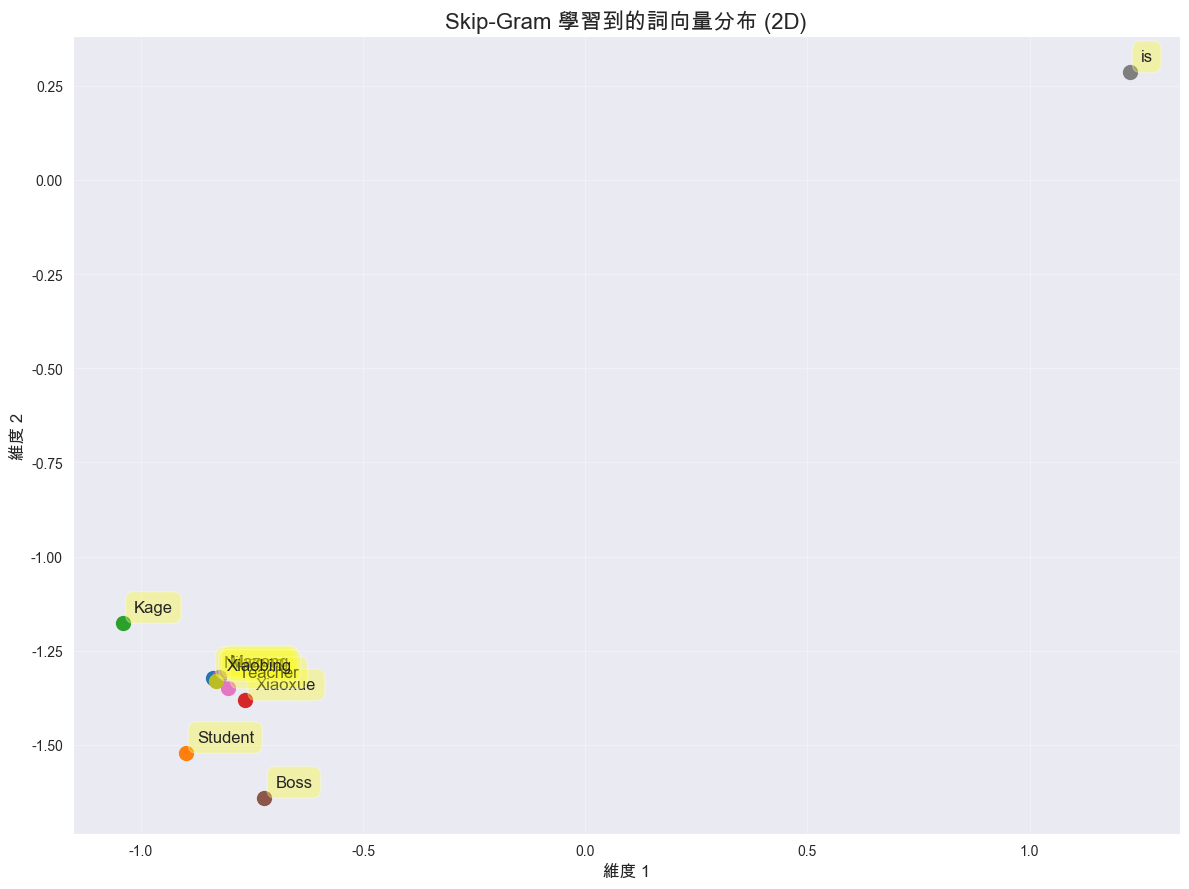

In [9]:
"""
Step 6: 成果觀察與可視化
訓練完後,我們把「詞向量矩陣」取出來,觀察單字在空間中的位置。
"""

import matplotlib.pyplot as plt

# 設定中文字體支援（macOS 適用）
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang TC', 'Heiti TC', 'STHeiti']
plt.rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題

# 提取訓練好的權重 (詞向量)
vectors = model.input_to_hidden.weight.detach().t().numpy()

plt.figure(figsize=(12, 9))
for word, idx in word_to_idx.items():
    x, y = vectors[idx][0], vectors[idx][1]
    plt.scatter(x, y, s=100)  # 增加點的大小
    plt.annotate(word, (x, y), 
                xytext=(8, 8),  # 增加偏移距離
                textcoords='offset points',
                fontsize=12,  # 設定字體大小
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3))  # 添加背景框

plt.title("Skip-Gram 學習到的詞向量分布 (2D)", fontsize=16)
plt.xlabel("維度 1", fontsize=12)
plt.ylabel("維度 2", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()  # 自動調整佈局避免標籤被截斷
plt.show()